![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

#### This fork belongs to: Lorena Gómez Diego & Marta Orient Cabañas

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [27]:
#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [5]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

lambda_c = 1.55

### 0.2. Functions by us

In [6]:
from upvfab_design_tools import MMI_EME, DC_EME
# Herramientas de diseño para ver la sección transversal y la propagación del modo

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [6]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
print(nitride_index[np.argmin(np.abs(wavelength - lambda_c))])

1.9983510626928518


In [14]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
print(box_index[np.argmin(np.abs(wavelength - lambda_c))])

1.457739700126459


### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

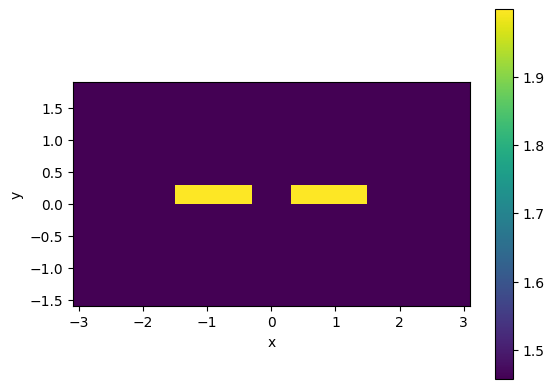

In [ ]:
dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()
#Tenemos dos índices de material nitruro que sabemos que es porque su índice es de 2.

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [9]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)
# Lo mismo que la anterior sesión
# En este caso, los 4 modos son guiados, ya que su índice efectivo es mayor que el índice del material de recubrimiento (box_index) y menor que el índice del material del núcleo (nitride_index).

2026-05-01 12:22:04.264 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [ ]:
dcoupler_cs.fraction_te
# Los dos primeros modos guiados son modos TE, y los otros dos son modos TM.

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [34]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

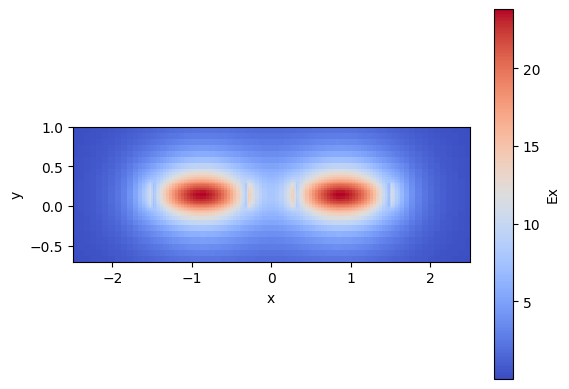

In [ ]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted --> el que hemos detectado con fraction_te/tm
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # Modo fundamental simétrico, beta(constante de propagación) con velocidad de propagación, beta=2pi/lambda_c*n_eff

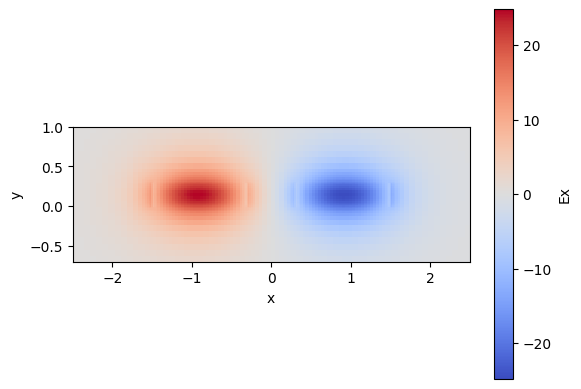

In [ ]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted --> el que hemos detectado con fraction_te/tm
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) 
#Modo fundamental antisimétrico, con simetría impar, con polo positivo y negativo se propaga con beta diferente por tener indices efectivos diferentes, por lo que se propagan a diferente velocidad y se acoplan con diferente longitud de acoplamiento.La fase viaja de distinta manera

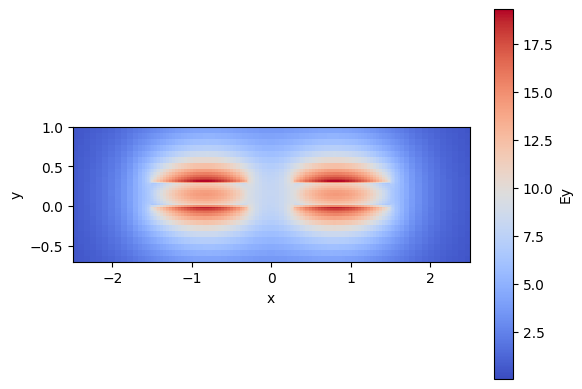

In [ ]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted --> el que hemos detectado con fraction_te/tm
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

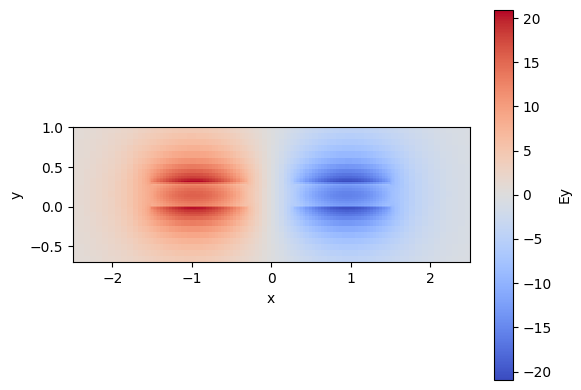

In [ ]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted --> el que hemos detectado con fraction_te/tm
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

# El menos confinado de todos, puesto que es el modo en el que el indice efectivo es el más bajo, por lo que se propaga con una velocidad más alta, y se acopla con una longitud de acoplamiento más larga.

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [10]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

# TM Modes: Modes 2 & 3
L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)
#Circuito sensible a la polarización. 

93.83767536700753
52.26022367744142


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [40]:
dcoupler_cs.coupling_length()
#Nos calcula Lpi, pero Camilo no suele usar esta función, porque parte de que no haya alternancia de modos. Calcular los índices efectivo del TE y TM y calcular Lpi con la fórmula.

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

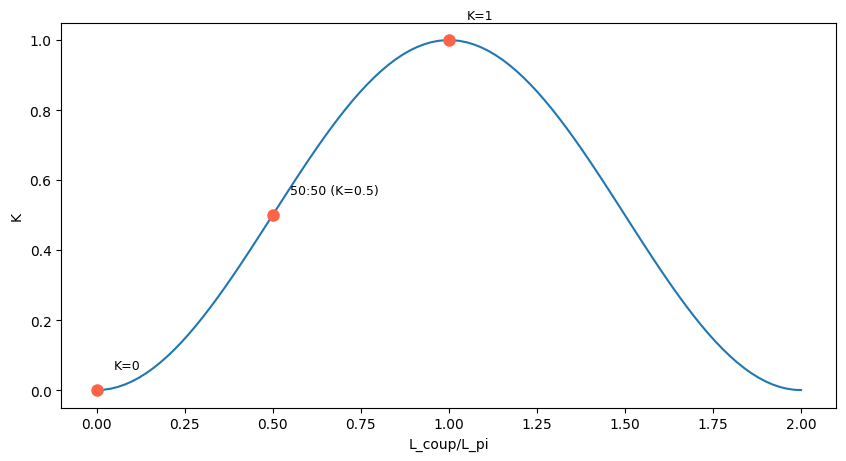

In [ ]:
L_over_Lpi = np.linspace(0, 2, 100) #representamos directamente el ratio
K = np.sin(np.pi / 2 * L_over_Lpi) ** 2
key_points = {0.0: 'K=0', 0.5: '50:50 (K=0.5)', 1.0: 'K=1'}
plt.figure(figsize=(10, 5))
plt.plot(L_over_Lpi, K)
plt.xlabel("L_coup/L_pi")
plt.ylabel("K")
for xk, label in key_points.items():
    yk = np.sin(np.pi / 2 * xk) ** 2
    plt.plot(xk, yk, 'o', markersize=8, color='tomato')
    plt.annotate(label, xy=(xk, yk), xytext=(xk + 0.05, yk + 0.06), fontsize=9)
plt.show()
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)


## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [57]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

# K es cuanta energía tengo en la guía cruzada 1-k es cuanta energía tengo en la guía directa. Lpi es la longitud de acoplamiento, es decir, la longitud que necesito para que toda la energía se acople a la guía cruzada. Si quiero un acoplador de 50/50 necesito Lpi/2, porque a Lpi/2 tengo el mismo campo en ambas guías.

/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  58.778412538503055  µm


/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/588 [00:00<?, ?it/s]

------- Pameters -------
MMI length 29.3892
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8899
Total OUT power: 0.8892
Excess loss [dB] =  0.5101
------------------------
Power over OUTs:  ['0.4451', '0.4441']
Ratio over OUTs ['0.5006', '0.4994']


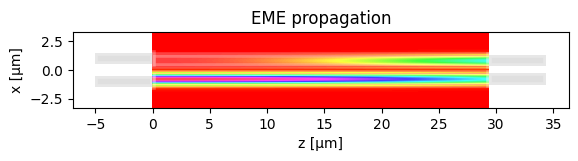

In [21]:
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI =0.5 *L_pi# Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/moricab/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:

gap = 0.2 µm -> L_pi = 17.662 µm, L_50/50 = 8.831 µm
gap = 0.4 µm -> L_pi = 32.675 µm, L_50/50 = 16.337 µm
gap = 0.6 µm -> L_pi = 58.778 µm, L_50/50 = 29.389 µm
gap = 0.8 µm -> L_pi = 104.314 µm, L_50/50 = 52.157 µm
gap = 1.0 µm -> L_pi = 183.313 µm, L_50/50 = 91.657 µm
gap = 1.2 µm -> L_pi = 319.739 µm, L_50/50 = 159.870 µm


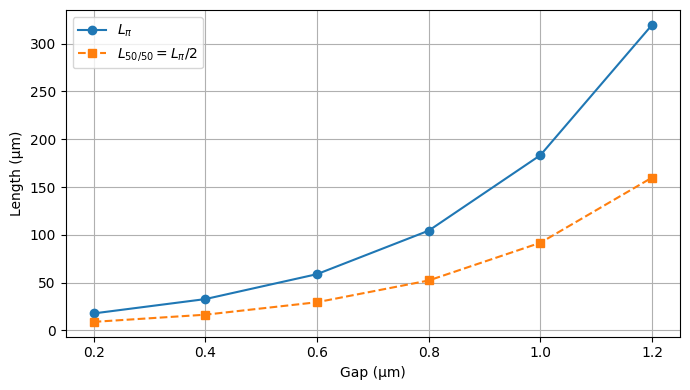

In [22]:
gaps = np.arange(0.2, 1.21, 0.2)
Lpi_vals = []
L50_vals = []

for g in gaps:
    m_sweep = DC_EME()
    m_sweep.MMI_num_modes = 12
    m_sweep.DC_wg_gap = g
    m_sweep.DC_wg_width = wg_width
    m_sweep.DC_N_waveguides = wg_N

    m_sweep.find_all_modes()
    Lpi = m_sweep.get_L_pi()

    Lpi_vals.append(Lpi)
    L50_vals.append(0.5 * Lpi)

for g, lp, l50 in zip(gaps, Lpi_vals, L50_vals):
    print(f"gap = {g:.1f} µm -> L_pi = {lp:.3f} µm, L_50/50 = {l50:.3f} µm")

plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_vals, "o-", label=r"$L_\pi$")
plt.plot(gaps, L50_vals, "s--", label=r"$L_{\mathrm{50/50}} = L_\pi/2$")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



### 1. Deep-etched waveguides

In [ ]:
# LO4 - minimum gap for uncoupled parallel waveguides
# TE0, w = 1.0 um, lambda = 1.55 um, L = 10 mm

lambda0 = 1.55 # um
wg_width = 1.0 # um
L = 10_000 # um = 10 mm
K_limit = 0.01

# HINT. Calculate manually the L_pi you may need to achieve K=0.01

L_pi_manual = (np.pi / 2 * L) / np.arcsin(np.sqrt(K_limit))
print("Manual L_pi required for K < 0.01 over 10 mm:", L_pi_manual, "µm")

Manual L_pi required for K < 0.01 over 10 mm: 156817.08768975522 µm


In [ ]:
# Optimal Lpi and gap calculation for DEEP etched waveguides

gaps = np.arange(1, 5.61, 0.2) # ajustamos el rango y el paso para encontrar el gap mínimo con más precisión

K_TE_shal = []
Lpi_shallow = []

for gap in gaps:
 # shallow etch
 dc_deep = gt.modes.WaveguideCoupler(
 wavelength=lambda0,
 core_width=(wg_width, wg_width),
 gap=gap,
 slab_thickness=0.0,
 core_material='sin',
 clad_material='sio2',
 core_thickness=300 * nm,
 num_modes=4,
 cache_path='.cache/',
 precision='double',
 max_grid_scaling=1.5,
 grid_resolution=20
 )

 neff_deep = dc_deep.n_eff
 Lpi = lambda0 / (2 * np.abs(neff_deep[0].real - neff_deep[1].real))
 Lpi_deep.append(Lpi)
 K_deep = np.sin(np.pi * L / (2 * Lpi))**2
 K_TE_deep.append(K_deep)


K_TE_deep = np.array(K_TE_deep)
Lpi_deep = np.array(Lpi_deep)

=== DEEP WAVEGUIDE ===
Gap mínimo = 4.00 µm
L_pi = 208929.31 µm
K = 0.005642


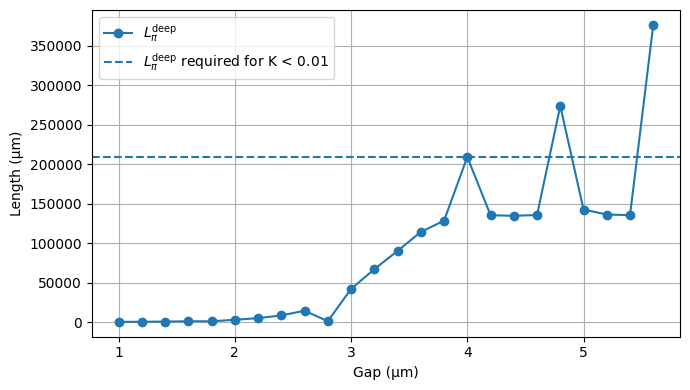

In [63]:
# RESULTADOS: 

# minimum gap index
L_pi_required = (np.pi / 2 * L) / np.arcsin(np.sqrt(K_limit))

idx_deep = np.where(Lpi_deep > L_pi_required)[0]

if len(idx_deep) > 0:
    deep_index = idx_deep[0]
    print("=== DEEP WAVEGUIDE ===")
    print(f"Gap mínimo = {gaps[deep_index]:.2f} µm")
    print(f"L_pi = {Lpi_deep[deep_index]:.2f} µm")
    print(f"K = {K_TE_deep[deep_index]:.6f}")
else:
    print("No valid deep gap found")

# PLOT

plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_deep, "o-", label=r"$L_{\pi}^{\mathrm{deep}}$")
plt.axhline(Lpi_deep[deep_index], linestyle='--', label=r"$L_{\pi}^{\mathrm{deep}}$ required for K < 0.01")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Como podemos ver, la Lpi mínima cae justo en un pico de simulación, lo que hace que dicha Lpi sea bastante superior a la que habíamos calculado manualmente, que eran 156817.087690 µm.

### 2. Shallow-etched waveguides

In [ ]:
# Optimal Lpi and gap calculation for SHALLOW etched waveguides

gaps = np.arange(1, 5.61, 0.2) # ajustamos el rango y el paso para encontrar el gap mínimo con más precisión

K_TE_shallow = []
Lpi_shallow = []

for gap in gaps:
 dc_shallow = gt.modes.WaveguideCoupler(
 wavelength=lambda0,
 core_width=(wg_width, wg_width),
 gap=gap,
 slab_thickness=150 * nm,
 core_material='sin',
 clad_material='sio2',
 core_thickness=300 * nm,
 num_modes=4,
 cache_path='.cache/',
 precision='double',
 max_grid_scaling=1.5,
 grid_resolution=20
 )

 neff_shallow = dc_shallow.n_eff
 Lpi = lambda0 / (2 * np.abs(neff_shallow[0].real - neff_shallow[1].real))
 Lpi_shallow.append(Lpi)
 K_shallow = np.sin(np.pi * L / (2 * Lpi))**2
 K_TE_shallow.append(K_shallow)

K_TE_shallow = np.array(K_TE_shallow)
Lpi_shallow = np.array(Lpi_shallow)

=== SHALLOW WAVEGUIDE ===
Gap mínimo = 5.00 µm
L_pi = 180067.81 µm
K = 0.007590


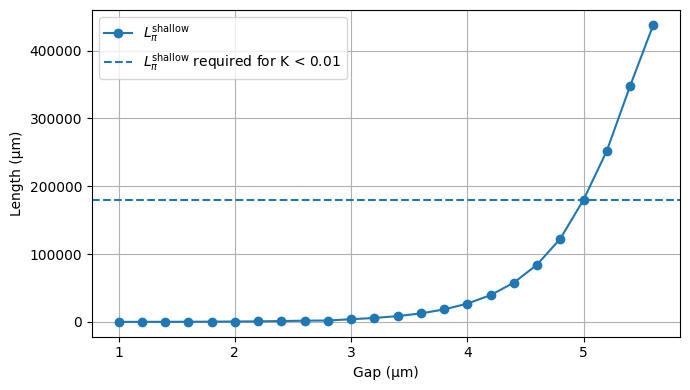

In [ ]:
# Results for the shallow etched waveguides:

# minimum gap index
idx_shallow = np.where(K_TE_shallow < K_limit)[0]

if len(idx_shallow) > 0:
    shallow_index = idx_shallow[0]
    print("=== SHALLOW WAVEGUIDE ===")
    print(f"Gap mínimo = {gaps[idx_shallow[0]]:.2f} µm")
    print(f"L_pi = {Lpi_shallow[shallow_index]:.2f} µm")
    print(f"K = {K_TE_shallow[shallow_index]:.6f}")
else:
    print("No valid shallow gap found")


# PLOT L_pi vs gap for shallow etched waveguides, and indicate the minimum L_pi required for K < 0.01
plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_shallow, "o-", label=r"$L_{\pi}^{\mathrm{shallow}}$")
plt.axhline(Lpi_shallow[shallow_index], linestyle='--', label=r"$L_{\pi}^{\mathrm{shallow}}$ required for K < 0.01")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [17]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=30, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff.real

2026-05-03 21:32:19.531 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_15433edbed8fc2d0.npz.


array([1.6786595 , 1.67512732, 1.66922847, 1.66094525, 1.65025312,
       1.63712124, 1.6215135 , 1.60339058, 1.58271457, 1.5774205 ,
       1.57388942, 1.56799588, 1.55972723, 1.5594584 , 1.54906903,
       1.53601168, 1.53362692, 1.52054265, 1.5053405 , 1.50269423,
       1.48257196, 1.4750929 , 1.46055739, 1.44602702, 1.44427255,
       1.44154639, 1.43845554, 1.43685358, 1.43133766, 1.43033094])

Vemos que los modos guiados son los 23 primeros, que son aquellos que cumplen*: n_clad < neff_modo_i < n_core

*Recordamos que n_core = 1.9984, n_clad = 1.4577

In [19]:
mmi_body_waveguide.fraction_tm

array([8.09649609e-06, 3.28171243e-05, 7.55025688e-05, 1.38554879e-04,
       2.25728075e-04, 3.42632298e-04, 4.97617536e-04, 7.03539352e-04,
       9.86991131e-04, 9.99761435e-01, 9.99044901e-01, 9.97861682e-01,
       9.96263661e-01, 1.40565190e-03, 9.94210025e-01, 9.90678071e-01,
       3.04573125e-03, 9.89089636e-01, 2.75223890e-03, 9.86146306e-01,
       9.83053282e-01, 4.22387720e-03, 9.80105567e-01, 2.89641600e-02,
       9.41278150e-01, 9.97581654e-01, 9.79115769e-01, 9.84856169e-01,
       1.60529148e-01, 8.09403634e-01])

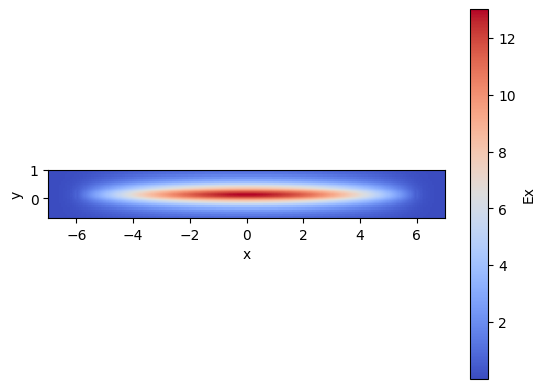

In [50]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # We see the hole waveguide 

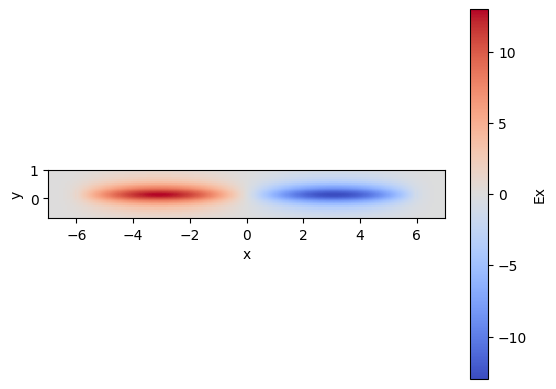

In [51]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # TE1, with a cut in the axis of major 

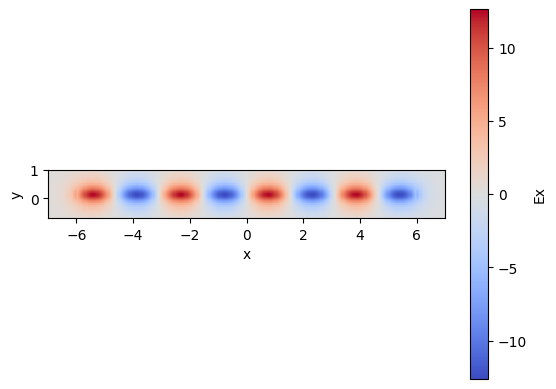

In [52]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #Modo TE sabemos el número de cortes

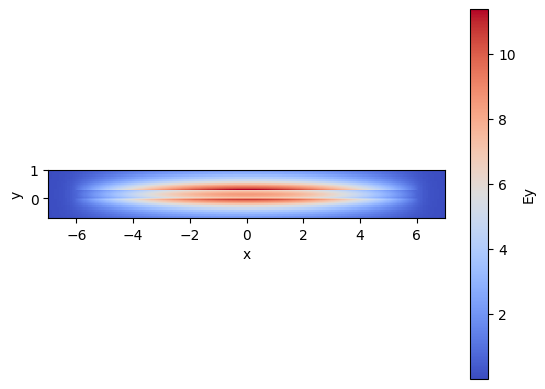

In [54]:
mmi_body_waveguide.plot_field(mode_index=9, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #interesante ver el modo 9, TM0, modo fundamental. Ningún corte en el eje mayor.

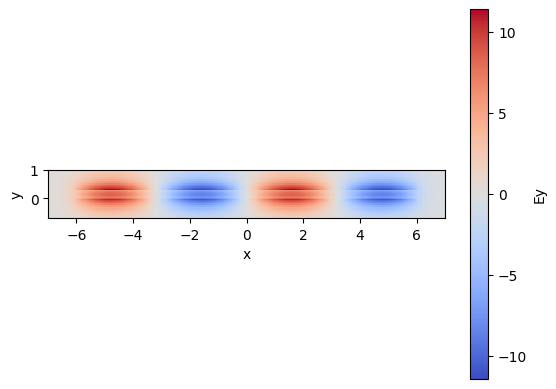

In [56]:
mmi_body_waveguide.plot_field(mode_index=12, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #Modo TM3, con 3 cortes en el eje de mayor transmisión

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [ ]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print ("L_pi = ", L_pi, "µm")

L_pi =  219.41119794400564 µm


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">


Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**


In [20]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width as specified in LO6.1

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 23 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
                    
                    # Hemos elegido 23, que son los modos que hemos visto que son guiados en el apartado anterior.

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607254912  µm


/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


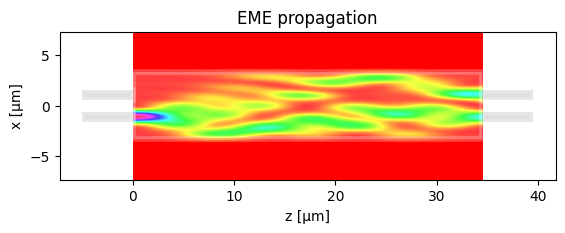

In [21]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # INTERFERENCIA PAREADA
m.n_OUT = 2 # DOS ENTRADAS DOS SALIDAS

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # ANCHO DEL MMI ENTRE 6 POR LO ESPECIFICADO EN LA TABLA
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) 

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi #WE DIVIDE lPI INTO 2 BECAUSE OF THE TABLE, 2 FOLD IMAGE DISTANCE

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


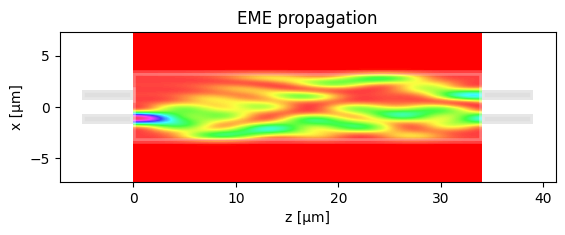

In [22]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [31]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.8 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607254912  µm


/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/689 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.0500
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9818
Total OUT power: 0.9587
Excess loss [dB] =  0.1832
------------------------
Power over OUTs:  ['0.4897', '0.4690']
Ratio over OUTs ['0.5108', '0.4892']


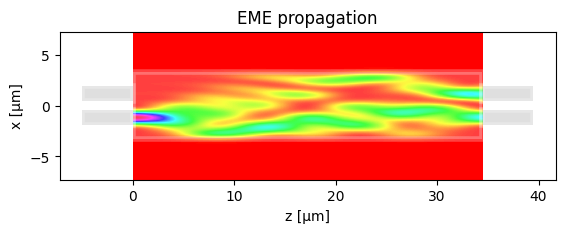

In [30]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.05 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [32]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 12  # MMI width
m.wg_width_dw = 1.2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544086205  µm


/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.5
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/6,-1/6,1/6,3/6]) + np.array([-1.4,-dy,dy,1.4])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16)*L_pi  # STUDENT
m.dL_MMI = -0.1 # STUDENT

## Extra - Exercises

### E1. Directional coupler gap dependence

#### 1. Deep-etched waveguides

In [ ]:
# STUDENT. Plot goes here

# Para deep-etched, aprovechamos y calculamos Lpi para TE y TM, para poder hacer la representación vs sweep del gap conjuntamente

gaps = np.arange(0.2, 2.41, 0.2) # definimos el rango como pedido en el enunciado

lambda0 = 1.55 # um
wg_width = 1.0 # um

Lpi_TE_deep = []
Lpi_TM_deep = []

for gap in gaps:
 # DEEP etch
 dc_deep = gt.modes.WaveguideCoupler(
 wavelength=lambda0,
 core_width=(wg_width, wg_width),
 gap=gap,
 slab_thickness=0.0,
 core_material='sin',
 clad_material='sio2',
 core_thickness=300 * nm,
 num_modes=4,
 cache_path='.cache/',
 precision='double',
 max_grid_scaling=1.5,
 grid_resolution=20
 )

 neff_deep = dc_deep.n_eff
 
 Lpi_TE = lambda0 / (2 * np.abs(neff_deep[0].real - neff_deep[1].real))
 Lpi_TE_deep.append(Lpi_TE)
 
 Lpi_TM = lambda0 / (2 * np.abs(neff_deep[2].real - neff_deep[3].real))
 Lpi_TM_deep.append(Lpi_TM)

Lpi_TE_deep = np.array(Lpi_TE_deep)
Lpi_TM_deep = np.array(Lpi_TM_deep)

2026-05-03 14:23:16.076 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-05-03 14:23:16.080 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
2026-05-03 14:23:16.088 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.
2026-05-03 14:23:16.093 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
2026-05-03 14:23:16.096 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
2026-05-03 14:23:16.100 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de78bc7bac7ad149.npz.
2026-05-03 14:23:16.108 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_69d8430ee5b848c9.npz.
2026-05-03 14:23:16.111 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

In [41]:
dcoupler_neff = dc_deep.n_eff.real
print(dcoupler_neff)

print(dc_deep.fraction_te)
print(dc_deep.fraction_tm)

[1.58342163 1.58332915 1.51760639 1.5169336 ]
[0.99281543 0.99281003 0.01127504 0.01144463]
[0.00718457 0.00718997 0.98872496 0.98855537]


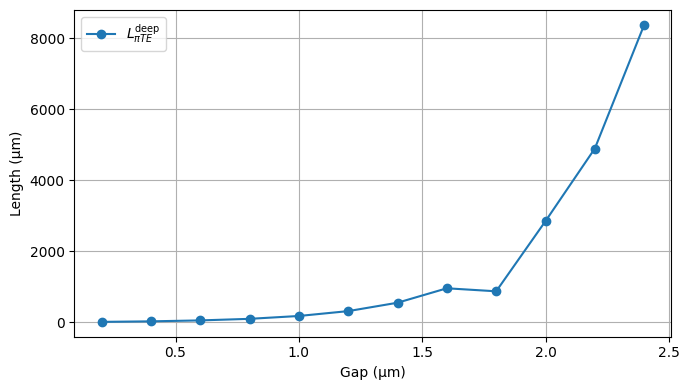

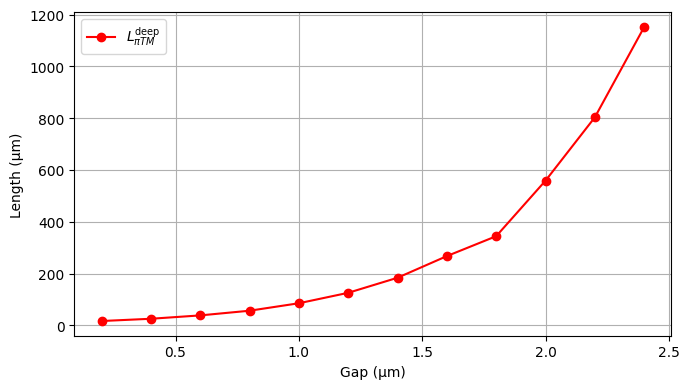

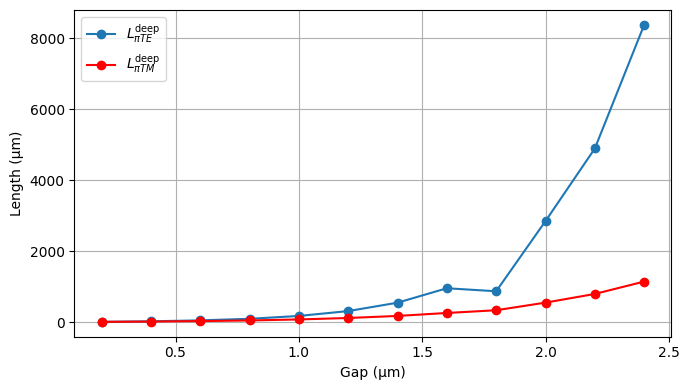

In [10]:
# RESULTADOS:

# PLOT

plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_TE_deep, "o-", label=r"$L_{\pi TE}^{\mathrm{deep}}$")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_TM_deep, "ro-", label=r"$L_{\pi TM}^{\mathrm{deep}}$")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_TE_deep, "o-", label=r"$L_{\pi TE}^{\mathrm{deep}}$")
plt.plot(gaps, Lpi_TM_deep, "ro-", label=r"$L_{\pi TM}^{\mathrm{deep}}$")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### 2. Shallow-etched waveguides

In [ ]:
# STUDENT. Plot goes here

# Para shallowetched, seguimos el mismo procedimiento que anteriormente

gaps = np.arange(0.2, 2.41, 0.2) # adefinimos el rango como pedido en el enunciado

lambda0 = 1.55 # um
wg_width = 1.0 # um

Lpi_TE_shallow = []
Lpi_TM_shallow = []

for gap in gaps:
 # SHALLOW etch
 dc_shallow = gt.modes.WaveguideCoupler(
 wavelength=lambda0,
 core_width=(wg_width, wg_width),
 gap=gap,
 slab_thickness=150 * nm,  # Slab thickness de 150nm para shallow
 core_material='sin',
 clad_material='sio2',
 core_thickness=300 * nm,
 num_modes=10,
 cache_path='.cache/',
 precision='double',
 max_grid_scaling=1.5,
 grid_resolution=20
 )

 neff_shallow = dc_shallow.n_eff
 
 Lpi_TE = lambda0 / (2 * np.abs(neff_shallow[0].real - neff_shallow[1].real))
 Lpi_TE_shallow.append(Lpi_TE)
 
#  Lpi_TM = lambda0 / (2 * np.abs(neff_shallow[2].real - neff_shallow[3].real))
#  Lpi_TM_shallow.append(Lpi_TM)

Lpi_TE_shallow = np.array(Lpi_TE_shallow)
# Lpi_TM_shallow = np.array(Lpi_TM_shallow)

2026-05-03 14:17:35.810 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c87172ff44246c31.npz.
2026-05-03 14:17:35.816 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_224c58facea02f5e.npz.
2026-05-03 14:17:35.822 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cb59e6eb537bb560.npz.
2026-05-03 14:17:35.823 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_083b2ac33628f0de.npz.
2026-05-03 14:17:35.826 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_348de0dac8fbd0c8.npz.
2026-05-03 14:17:35.827 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_514bfe58be6d9400.npz.
2026-05-03 14:17:35.832 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f74f8d5eaecacd8f.npz.
2026-05-03 14:17:35.838 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

In [ ]:
dcoupler_neff = dc_shallow.n_eff.real
print("neff:", dcoupler_neff)

# Todos los modos son guiados menos el último

neff: [1.60715471 1.60654218 1.5315381  1.53153548 1.52689434 1.52452835
 1.50979192 1.47776884 1.47012715 1.44763361]


In [ ]:
print("Fraction TE:", dc_shallow.fraction_te)
print("Fraction TM:", dc_shallow.fraction_tm)

Fraction TE: [0.99607419 0.99602478 0.42512384 0.06705656 0.44385506 0.87876609
 0.99452925 0.98280001 0.01249839 0.02468384]
Fraction TM: [0.00392581 0.00397522 0.57487616 0.93294344 0.55614494 0.12123391
 0.00547075 0.01719999 0.98750161 0.97531616]


En guías shallow-etched, la presencia del slab reduce el confinamiento vertical, afectando especialmente a los modos TM, que tienden a deslocalizarse fuera del núcleo. Al analizar neff y las fracciones TE/TM, se observa que muchos modos son híbridos y no existe un par claro de supermodos TM (par/impar).

Por ello, el análisis del acoplamiento para TM en esta configuración no es fiable y sus resultados no se consideran, ya que carecen de un significado físico claro.

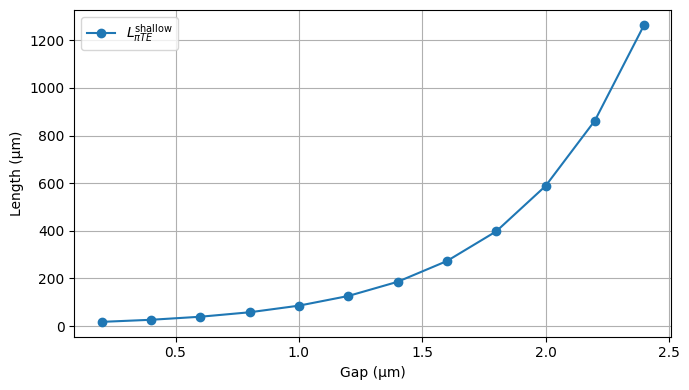

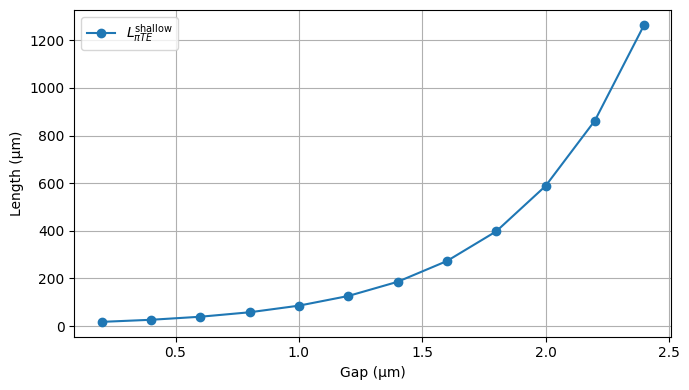

In [36]:
# RESULTADOS:

# PLOT

plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_TE_shallow, "o-", label=r"$L_{\pi TE}^{\mathrm{shallow}}$")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# plt.figure(figsize=(7, 4))
# plt.plot(gaps, Lpi_TM_shallow, "ro-", label=r"$L_{\pi TM}^{\mathrm{shallow}}$")
# plt.xlabel("Gap (µm)")
# plt.ylabel("Length (µm)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()


plt.figure(figsize=(7, 4))
plt.plot(gaps, Lpi_TE_shallow, "o-", label=r"$L_{\pi TE}^{\mathrm{shallow}}$")
# plt.plot(gaps, Lpi_TM_shallow, "ro-", label=r"$L_{\pi TM}^{\mathrm{shallow}}$")
plt.xlabel("Gap (µm)")
plt.ylabel("Length (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### E2. Directional coupler wavelength dependence

#### 1. Deep-etched waveguides

In [ ]:
wavelength = np.arange(1.5, 1.71, 0.021) # definimos el rango como pedido en el enunciado

Lpi_TE_deep = []
Lpi_TM_deep = []

for wv in wavelength: 
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wv, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=600 * nm,
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    deep_neff = deep_dcoupler_cs.n_eff
    
L_pi_TE = 0.5*wavelength/(neff[:,0].real-neff[:,1].real)
L_pi_TM = 0.5*wavelength/(neff[:,2].real-neff[:,3].real)
    

Lpi_TE_deep = np.array(Lpi_TE_deep)
Lpi_TM_deep = np.array(Lpi_TM_deep)


2026-05-03 21:55:32.070 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fc2c62c75e0d5f6e.npz.
2026-05-03 21:55:32.084 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1a77e3dddb7811c2.npz.
2026-05-03 21:55:32.088 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b96d4b12910f5108.npz.
2026-05-03 21:55:32.090 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d3a1f13e9403193d.npz.
2026-05-03 21:55:32.092 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_21423a6ffa8b05b4.npz.
2026-05-03 21:55:32.095 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_313c71a2e6239a53.npz.
2026-05-03 21:55:32.099 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_a0f322921307e16c.npz.
2026-05-03 21:55:32.102 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

ValueError: x and y must be the same size

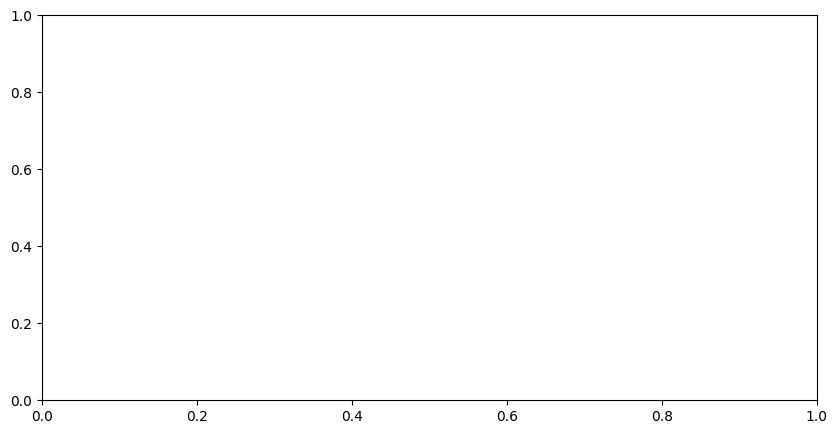

In [37]:
# PLOT: 

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, Lpi_TE_deep,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.scatter(wavelength, Lpi_TM_deep,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, Lpi_TE_deep,label='TE')
plt.plot(wavelength, Lpi_TM_deep,label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

#### 2. Shallow-etched waveguides

In [70]:
wavelength = np.arange(1.5, 1.71, 0.05) # definimos el rango como pedido en el enunciado

Lpi_TE_shallow = []
Lpi_TM_shallow = []

for wv in wavelength: 
    shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wv, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=600 * nm,
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=6, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    shallow_neff = shallow_dcoupler_cs.n_eff
    
    Lpi_TE = lambda0 / (2 * np.abs(shallow_neff[0].real - shallow_neff[1].real))
    Lpi_TE_shallow.append(Lpi_TE)
    
    Lpi_TM = lambda0 / (2 * np.abs(shallow_neff[2].real - shallow_neff[5].real))
    Lpi_TM_shallow.append(Lpi_TM)
    

Lpi_TE_shallow = np.array(Lpi_TE_shallow)
Lpi_TM_shallow = np.array(Lpi_TM_shallow)


2026-05-03 18:11:50.061 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_29275665d8177d38.npz.
2026-05-03 18:11:50.065 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_675892dba083647f.npz.
2026-05-03 18:11:50.070 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_6da6597be4d588e6.npz.
2026-05-03 18:11:50.072 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8688194d08c249b4.npz.
2026-05-03 18:11:50.073 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1d7382997dcda909.npz.


In [68]:
print("neff:", shallow_neff.real)


neff: [1.59496789 1.56925923 1.52308544 1.51536874 1.50794483 1.496114  ]


In [69]:
print("Fraction TE:", shallow_dcoupler_cs.fraction_te)
print("Fraction TM:", shallow_dcoupler_cs.fraction_tm)

Fraction TE: [0.99631816 0.99606483 0.00736442 0.98736495 0.99615359 0.01820653]
Fraction TM: [0.00368184 0.00393517 0.99263558 0.01263505 0.00384641 0.98179347]


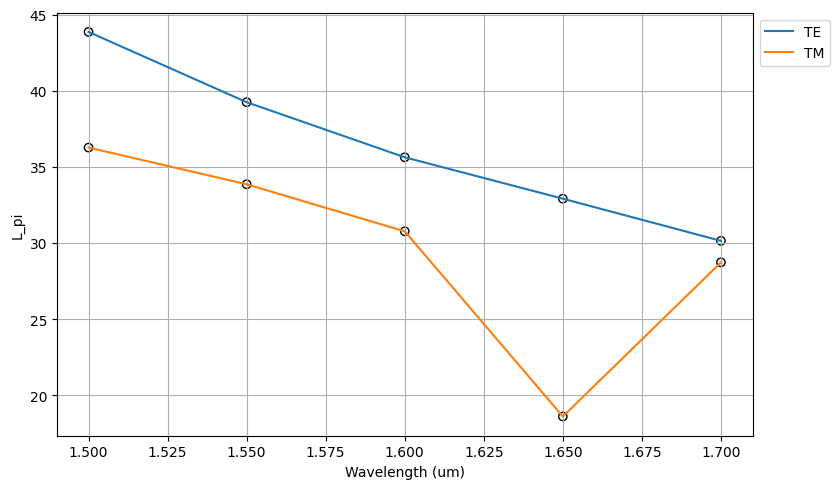

In [71]:
# PLOT: 

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, Lpi_TE_shallow,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.scatter(wavelength, Lpi_TM_shallow,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, Lpi_TE_shallow,label='TE')
plt.plot(wavelength, Lpi_TM_shallow,label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points